In [1]:
# import necessary libraries

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import folium

from shapely import wkt
from shapely.ops import transform

#### Loading EMODnet metadata

In [2]:
csv_path = "../data/windfarmspoly.csv"

df = pd.read_csv(csv_path)
df.head()

,FID,country,name,n_turbines,power_mw,status,type_inst,updateyear,year,dist_coast,area_sqkm,notes,shape_leng,shape_area,the_geom
0,windfarmspoly.103,France,Saint-Nazaire,80.0,480.0,Production,NaN,2025.0,2022.0,11306.476693,78.108636,NaN,0.510724,0.009266,MULTIPOLYGON (((47.20983333314189 -2.659999999...
1,windfarmspoly.44,Denmark,Samsa,10.0,23.0,Production,NaN,2025.0,2003.0,3456.959776,0.882531,NaN,0.060561,0.000126,MULTIPOLYGON (((55.70968655219269 10.584767397...
2,windfarmspoly.46,Denmark,Anholt,111.0,399.6,Production,Grounded,2026.0,2012.0,15488.518291,90.475307,NaN,0.578814,0.013228,MULTIPOLYGON (((56.57339388851722 11.323086007...
3,windfarmspoly.48,Denmark,Frederikshavn Offshore,3.0,10.6,Production,NaN,2025.0,2003.0,0.000000,0.241544,NaN,0.027363,0.000036,MULTIPOLYGON (((57.444760660775955 10.55700385...
4,windfarmspoly.51,Denmark,Kriegers Flak K2-K3,72.0,605.0,Production,NaN,2026.0,2021.0,13553.548732,173.145563,NaN,1.078007,0.024318,MULTIPOLYGON (((54.971493760928354 12.90487209...


In [3]:
# Check the structure of the DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   FID         600 non-null    str    
 1   country     600 non-null    str    
 2   name        579 non-null    str    
 3   n_turbines  241 non-null    float64
 4   power_mw    420 non-null    float64
 5   status      600 non-null    str    
 6   type_inst   147 non-null    str    
 7   updateyear  393 non-null    float64
 8   year        151 non-null    float64
 9   dist_coast  600 non-null    float64
 10  area_sqkm   600 non-null    float64
 11  notes       0 non-null      float64
 12  shape_leng  600 non-null    float64
 13  shape_area  600 non-null    float64
 14  the_geom    600 non-null    str    
dtypes: float64(9), str(6)
memory usage: 2.4 MB


In [4]:
# Check the column names
df.columns

Index(['FID', 'country', 'name', 'n_turbines', 'power_mw', 'status',
       'type_inst', 'updateyear', 'year', 'dist_coast', 'area_sqkm', 'notes',
       'shape_leng', 'shape_area', 'the_geom'],
      dtype='str')

In [5]:
# Check how many unique values are in each column
df.nunique()

FID           600
country        15
name          569
n_turbines     91
power_mw      202
status          6
type_inst       2
updateyear     10
year           36
dist_coast    588
area_sqkm     598
notes           0
shape_leng    599
shape_area    597
the_geom      599
dtype: int64

In [6]:
#convert the WKT geometry to shapely geometry
def swap_lat_lon(geometry):
    return transform(lambda x, y: (y, x), geometry)

# Convert the WKT geometry to shapely geometry
df["geometry"] = df["the_geom"].apply(wkt.loads)

# The CSV seems to store coordinates as lat/lon and geopandas expects them as lon/lat
df["geometry"] = df["geometry"].apply(swap_lat_lon)

In [7]:
df.head(3)

,FID,country,name,n_turbines,power_mw,status,type_inst,updateyear,year,dist_coast,area_sqkm,notes,shape_leng,shape_area,the_geom,geometry
0,windfarmspoly.103,France,Saint-Nazaire,80.0,480.0,Production,NaN,2025.0,2022.0,11306.476693,78.108636,NaN,0.510724,0.009266,MULTIPOLYGON (((47.20983333314189 -2.659999999...,MULTIPOLYGON (((-2.6599999998001067 47.2098333...
1,windfarmspoly.44,Denmark,Samsa,10.0,23.0,Production,NaN,2025.0,2003.0,3456.959776,0.882531,NaN,0.060561,0.000126,MULTIPOLYGON (((55.70968655219269 10.584767397...,MULTIPOLYGON (((10.584767397897167 55.70968655...
2,windfarmspoly.46,Denmark,Anholt,111.0,399.6,Production,Grounded,2026.0,2012.0,15488.518291,90.475307,NaN,0.578814,0.013228,MULTIPOLYGON (((56.57339388851722 11.323086007...,MULTIPOLYGON (((11.323086007912991 56.57339388...


In [8]:
# create GeoDataFrame

gdf = gpd.GeoDataFrame(
    df,
    geometry="geometry",
    crs="EPSG:4326"
)

gdf.head()

,FID,country,name,n_turbines,power_mw,status,type_inst,updateyear,year,dist_coast,area_sqkm,notes,shape_leng,shape_area,the_geom,geometry
0,windfarmspoly.103,France,Saint-Nazaire,80.0,480.0,Production,NaN,2025.0,2022.0,11306.476693,78.108636,NaN,0.510724,0.009266,MULTIPOLYGON (((47.20983333314189 -2.659999999...,"MULTIPOLYGON (((-2.66 47.20983, -2.635 47.1783..."
1,windfarmspoly.44,Denmark,Samsa,10.0,23.0,Production,NaN,2025.0,2003.0,3456.959776,0.882531,NaN,0.060561,0.000126,MULTIPOLYGON (((55.70968655219269 10.584767397...,"MULTIPOLYGON (((10.58477 55.70969, 10.5846 55...."
2,windfarmspoly.46,Denmark,Anholt,111.0,399.6,Production,Grounded,2026.0,2012.0,15488.518291,90.475307,NaN,0.578814,0.013228,MULTIPOLYGON (((56.57339388851722 11.323086007...,"MULTIPOLYGON (((11.32309 56.57339, 11.31298 56..."
3,windfarmspoly.48,Denmark,Frederikshavn Offshore,3.0,10.6,Production,NaN,2025.0,2003.0,0.000000,0.241544,NaN,0.027363,0.000036,MULTIPOLYGON (((57.444760660775955 10.55700385...,"MULTIPOLYGON (((10.557 57.44476, 10.5569 57.44..."
4,windfarmspoly.51,Denmark,Kriegers Flak K2-K3,72.0,605.0,Production,NaN,2026.0,2021.0,13553.548732,173.145563,NaN,1.078007,0.024318,MULTIPOLYGON (((54.971493760928354 12.90487209...,"MULTIPOLYGON (((12.90487 54.97149, 12.86417 54..."


In [9]:
print(type(gdf))
print(gdf.geometry.name)
print(gdf.geometry.head())

<class 'geopandas.geodataframe.GeoDataFrame'>
geometry
0    MULTIPOLYGON (((-2.66 47.20983, -2.635 47.1783...
1    MULTIPOLYGON (((10.58477 55.70969, 10.5846 55....
2    MULTIPOLYGON (((11.32309 56.57339, 11.31298 56...
3    MULTIPOLYGON (((10.557 57.44476, 10.5569 57.44...
4    MULTIPOLYGON (((12.90487 54.97149, 12.86417 54...
Name: geometry, dtype: geometry


In [10]:
os.path.exists("../data")

NameError: name 'os' is not defined

In [11]:
gdf.to_file("../data/gdf.gpkg",driver="GPKG")
type(gdf)

FieldError: Error adding field 'FID' to layer

In [12]:
# convert to metres for distance calculations

gdf_metres = gdf.to_crs(epsg=32631)
print(type(gdf_metres))
gdf_metres.crs

<class 'geopandas.geodataframe.GeoDataFrame'>


<Projected CRS: EPSG:32631>
Name: WGS 84 / UTM zone 31N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 0°E and 6°E, northern hemisphere between equator and 84°N, onshore and offshore. Algeria. Andorra. Belgium. Benin. Burkina Faso. Denmark - North Sea. France. Germany - North Sea. Ghana. Luxembourg. Mali. Netherlands. Niger. Nigeria. Norway. Spain. Togo. United Kingdom (UK) - North Sea.
- bounds: (0.0, 0.0, 6.0, 84.0)
Coordinate Operation:
- name: UTM zone 31N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [13]:
gdf_metres.columns

Index(['FID', 'country', 'name', 'n_turbines', 'power_mw', 'status',
       'type_inst', 'updateyear', 'year', 'dist_coast', 'area_sqkm', 'notes',
       'shape_leng', 'shape_area', 'the_geom', 'geometry'],
      dtype='str')

In [14]:
# inspect useful columns

gdf_metres = gdf_metres[
    ["name", "country", "status", "power_mw", "n_turbines", "area_sqkm", "type_inst", "geometry"]
].copy()

gdf_metres.head()

,name,country,status,power_mw,n_turbines,area_sqkm,type_inst,geometry
0,Saint-Nazaire,France,Production,480.0,80.0,78.108636,NaN,"MULTIPOLYGON (((71436.602 5244041.04, 73075.75..."
1,Samsa,Denmark,Production,23.0,10.0,0.882531,NaN,"MULTIPOLYGON (((976074.268 6199866.032, 976063..."
2,Anholt,Denmark,Production,399.6,111.0,90.475307,Grounded,"MULTIPOLYGON (((1010669.652 6300943.767, 10101..."
3,Frederikshavn Offshore,Denmark,Production,10.6,3.0,0.241544,NaN,"MULTIPOLYGON (((953025.588 6392135.79, 953018...."
4,Kriegers Flak K2-K3,Denmark,Production,605.0,72.0,173.145563,NaN,"MULTIPOLYGON (((1132960.161 6136606.413, 11304..."


In [15]:
gdf_metres.country.value_counts()

country
United Kingdom    213
Germany            93
Sweden             70
Denmark            56
Netherlands        39
France             27
Ireland            22
Spain              21
Belgium            18
Finland            18
Lithuania           7
Poland              7
Latvia              5
Estonia             3
Portugal            1
Name: count, dtype: int64

In [16]:
def get_data(country):
    return gdf_metres[gdf_metres["country"] == country].sort_values(["status", "power_mw"], ascending=False)

get_data("Belgium")

,name,country,status,power_mw,n_turbines,area_sqkm,type_inst,geometry
16,Norther,Belgium,Production,369.60,44.0,38.442050,Grounded,"MULTIPOLYGON (((502777.3 5706764.815, 498146.6..."
210,C-Power,Belgium,Production,325.20,54.0,19.852823,Grounded,"MULTIPOLYGON (((495673.008 5707997.117, 495000..."
15,Rentel,Belgium,Production,309.00,42.0,23.265816,Grounded,"MULTIPOLYGON (((492188.73 5715538.777, 493455...."
17,Seamade (SeaStar),Belgium,Production,252.00,30.0,18.425859,Grounded,"MULTIPOLYGON (((490574.205 5718251.336, 489176..."
111,Mermaid,Belgium,Production,235.20,28.0,16.267913,NaN,"MULTIPOLYGON (((483097 5728870, 480483 5726839..."
18,Northwester 2,Belgium,Production,219.00,23.0,11.729325,Grounded,"MULTIPOLYGON (((485101.773 5728897.557, 482816..."
112,Northwind,Belgium,Production,216.00,72.0,13.847117,Grounded,"MULTIPOLYGON (((494670 5718099, 493520 5717355..."
40,Thorntonbank Part 2,Belgium,Production,184.50,30.0,9.169186,NaN,"MULTIPOLYGON (((500233.409 5714532.005, 500780..."
208,Belwind I & II,Belgium,Production,171.00,56.0,13.201102,NaN,"MULTIPOLYGON (((486901.3 5728408.25, 488885.03..."
14,Belwind phase 1,Belgium,Production,165.00,55.0,14.740745,NaN,"MULTIPOLYGON (((486902.153 5728406.7, 487882.8..."


In [17]:
get_data("Sweden")

,name,country,status,power_mw,n_turbines,area_sqkm,type_inst,geometry
106,Bockstigen 1,Sweden,Production,2750.0,5.0,0.741834,NaN,"MULTIPOLYGON (((1415618.692 6424060.567, 14145..."
108,Lillgrund,Sweden,Production,110.4,48.0,7.087603,NaN,"MULTIPOLYGON (((1115058.789 6195175.506, 11149..."
105,Kårehamn,Sweden,Production,48.0,16.0,4.401113,NaN,"MULTIPOLYGON (((1350885.907 6401833.335, 13506..."
206,Sylen,Sweden,Planned,5000.0,261.0,525.258770,NaN,"MULTIPOLYGON (((1325369.817 6924275.082, 13381..."
226,Gävle Öst Havsvindpark,Sweden,Planned,4860.0,NaN,399.837660,NaN,"MULTIPOLYGON (((1328437.164 6895501.467, 13285..."
...,...,...,...,...,...,...,...,...
263,Kattegatt Syd,Sweden,Approved,1200.0,NaN,102.771640,NaN,"MULTIPOLYGON (((1047011.529 6340259.128, 10501..."
223,Storgrundet,Sweden,Approved,1020.0,70.0,61.673642,NaN,"MULTIPOLYGON (((1278094.336 6868401.37, 128039..."
224,Gretas Klackar 2,Sweden,Approved,1020.0,38.0,50.788374,NaN,"MULTIPOLYGON (((1287411.166 6878859.742, 12871..."
211,Galene,Sweden,Approved,400.0,21.0,55.185729,NaN,"MULTIPOLYGON (((1034526.124 6351790.739, 10279..."


Selected Norther as the target farm because most of the farms in the Denmark are in Production which makes it one of the ideal locations as we have the neighboring farms data.

In [18]:
# search for target farm

search_term = "Belgium"

candidate_farms = get_data(search_term)
candidate_farms

,name,country,status,power_mw,n_turbines,area_sqkm,type_inst,geometry
16,Norther,Belgium,Production,369.60,44.0,38.442050,Grounded,"MULTIPOLYGON (((502777.3 5706764.815, 498146.6..."
210,C-Power,Belgium,Production,325.20,54.0,19.852823,Grounded,"MULTIPOLYGON (((495673.008 5707997.117, 495000..."
15,Rentel,Belgium,Production,309.00,42.0,23.265816,Grounded,"MULTIPOLYGON (((492188.73 5715538.777, 493455...."
17,Seamade (SeaStar),Belgium,Production,252.00,30.0,18.425859,Grounded,"MULTIPOLYGON (((490574.205 5718251.336, 489176..."
111,Mermaid,Belgium,Production,235.20,28.0,16.267913,NaN,"MULTIPOLYGON (((483097 5728870, 480483 5726839..."
18,Northwester 2,Belgium,Production,219.00,23.0,11.729325,Grounded,"MULTIPOLYGON (((485101.773 5728897.557, 482816..."
112,Northwind,Belgium,Production,216.00,72.0,13.847117,Grounded,"MULTIPOLYGON (((494670 5718099, 493520 5717355..."
40,Thorntonbank Part 2,Belgium,Production,184.50,30.0,9.169186,NaN,"MULTIPOLYGON (((500233.409 5714532.005, 500780..."
208,Belwind I & II,Belgium,Production,171.00,56.0,13.201102,NaN,"MULTIPOLYGON (((486901.3 5728408.25, 488885.03..."
14,Belwind phase 1,Belgium,Production,165.00,55.0,14.740745,NaN,"MULTIPOLYGON (((486902.153 5728406.7, 487882.8..."


In [19]:



candidate_farms.to_file("../data/candidate_farms.gpkg",driver="GPKG")

In [20]:
candidate_farms.loc[candidate_farms["status"] != "Production"]

,name,country,status,power_mw,n_turbines,area_sqkm,type_inst,geometry
126,Princess Elisabeth Zone Lot 3,Belgium,Planned,1400.0,NaN,106.738157,NaN,"MULTIPOLYGON (((464804.436 5709456.218, 464780..."
124,Princess Elisabeth Zone Lot 2.1,Belgium,Planned,700.0,NaN,12.051753,NaN,"MULTIPOLYGON (((470644.704 5712386.807, 468954..."
125,Princess Elisabeth Zone Lot 2.2,Belgium,Planned,700.0,NaN,91.338855,NaN,"MULTIPOLYGON (((454394.973 5691206.454, 454299..."
129,Princess Elisabeth Zone Lot 1,Belgium,Planned,700.0,NaN,45.990260,NaN,"MULTIPOLYGON (((470915.491 5724311.849, 472950..."


<class 'geopandas.geodataframe.GeoDataFrame'>


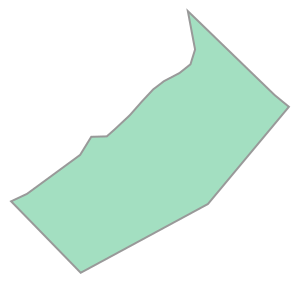

In [21]:
# select target farm

target = candidate_farms.loc[candidate_farms['name'] == "Norther"]

print(type(target))
target.geometry.iloc[0]

#### Target Farm Selection

**Norther** is selected as the target farm for the following reasons:

1. **Dense cluster location**: Norther sits at the centre of the Belgian-Dutch offshore wind cluster, surrounded by 14+ operational farms within 20 km
2. **Future uncertainty**: 4 massive Princess Elisabeth Zone lots (3,500 MW total, all "Planned") sit 25-30 km away — their turbine layouts are unknown, creating exactly the scenario this project addresses
3. **Cross-border interactions**: Dutch Borssele farms are <1 km away; French Dunkerque is ~48 km — realistic multi-country scenario
4. **Sufficient scale**: 369.6 MW with 44 turbines (MHI Vestas V164-8.0 MW) — large enough to show meaningful inter-farm wake effects
5. **Operational status**: As a Production farm with known parameters, it provides a baseline for validation

In [22]:
distance_km = 50
distance_m = distance_km * 1000

target_idx = candidate_farms.index[0]
target = gdf_metres.loc[target_idx]
print(type(target))

neighbours = gdf_metres[
    (gdf_metres.geometry.distance(target.geometry) <= distance_m)
    & (gdf_metres.index != target_idx)
].copy()

# remove polygons that overlap/intersect the target
neighbours = neighbours[
    ~neighbours.geometry.intersects(target.geometry)
].copy()

neighbours["distance_km"] = neighbours.geometry.distance(target.geometry) / 1000

print (f"Found {len(neighbours)} neighbours within {distance_km} km of the target farm.")

neighbours[
    ["name", "country", "status", "power_mw", "distance_km", "n_turbines", "area_sqkm", "geometry"]
].sort_values("distance_km")

<class 'pandas.Series'>
Found 26 neighbours within 50 km of the target farm.


,name,country,status,power_mw,distance_km,n_turbines,area_sqkm,geometry
562,Windenergiegebied Borssele zuidzijde,Netherlands,Planned,NaN,0.499272,NaN,247.772415,"MULTIPOLYGON (((502520.264 5728436.943, 503497..."
210,C-Power,Belgium,Production,325.20,0.998707,54.0,19.852823,"MULTIPOLYGON (((495673.008 5707997.117, 495000..."
39,Thorntonbank Part 1,Belgium,Production,30.45,0.999263,6.0,10.682412,"MULTIPOLYGON (((491928.853 5710640.416, 493647..."
50,Borssele Kavel II,Netherlands,Production,376.00,1.000421,47.0,63.527793,"MULTIPOLYGON (((503352.064 5727468.359, 503486..."
249,Borssele,Netherlands,Planned,1502.50,1.000421,NaN,344.945156,"MULTIPOLYGON (((507087.053 5716811.658, 504039..."
40,Thorntonbank Part 2,Belgium,Production,184.50,1.027585,30.0,9.169186,"MULTIPOLYGON (((500233.409 5714532.005, 500780..."
15,Rentel,Belgium,Production,309.00,2.510876,42.0,23.265816,"MULTIPOLYGON (((492188.73 5715538.777, 493455...."
51,Borssele Kavel III,Netherlands,Production,351.50,3.059567,37.0,71.464014,"MULTIPOLYGON (((500555.554 5727236.973, 500620..."
112,Northwind,Belgium,Production,216.00,8.154142,72.0,13.847117,"MULTIPOLYGON (((494670 5718099, 493520 5717355..."
17,Seamade (SeaStar),Belgium,Production,252.00,11.751042,30.0,18.425859,"MULTIPOLYGON (((490574.205 5718251.336, 489176..."


In [23]:
def deduplicate_neighbours(neighbours_gdf, overlap_threshold=0.5):
    """
    Remove duplicate/overlapping farm entries from the neighbours GeoDataFrame.
    
    Strategy:
    - Apply manual rules for known duplicate clusters (Belwind, Borssele).
    - Then check for any remaining spatial overlaps automatically.
    
    Parameters
    ----------
    neighbours_gdf : GeoDataFrame
        The neighbours dataframe with geometry in projected CRS (metres)
    overlap_threshold : float
        Fraction of overlap (relative to smaller polygon) above which two farms
        are considered duplicates. Default 0.5 (50% overlap).
    
    Returns
    -------
    GeoDataFrame
        Deduplicated neighbours
    """
    
    # --- Manual deduplication rules ---
    
    # RULE 1: Belwind cluster
    # Keep 'Belwind phase 1' + 'Nobelwind' as two separate physical farms.
    # Drop 'Belwind I & II' (aggregate) and zone-level entries.
    belwind_drop = [
        'Belwind I & II',
        'Belwind phase 2 (Nobelwind) (Zone 1)',
        'Belwind phase 2 (Nobelwind) (Zone 2)',
    ]
    
    # RULE 2: Borssele cluster
    # Keep individual kavels (I, II, III, IV, V). Drop the aggregate planned entry.
    borssele_drop = [
        'Borssele',
    ]
    
    drop_names = belwind_drop + borssele_drop
    deduped = neighbours_gdf[~neighbours_gdf['name'].isin(drop_names)].copy()
    
    # --- Automated spatial overlap check ---
    to_drop_idx = set()
    indices = deduped.index.tolist()
    
    for i in range(len(indices)):
        if indices[i] in to_drop_idx:
            continue
        for j in range(i + 1, len(indices)):
            if indices[j] in to_drop_idx:
                continue
            
            geom_i = deduped.loc[indices[i], 'geometry']
            geom_j = deduped.loc[indices[j], 'geometry']
            
            if geom_i.intersects(geom_j):
                intersection_area = geom_i.intersection(geom_j).area
                smaller_area = min(geom_i.area, geom_j.area)
                
                if smaller_area > 0:
                    overlap_frac = intersection_area / smaller_area
                    
                    if overlap_frac > overlap_threshold:
                        # Keep the one with more complete data (n_turbines available)
                        has_turbines_i = pd.notna(deduped.loc[indices[i], 'n_turbines'])
                        has_turbines_j = pd.notna(deduped.loc[indices[j], 'n_turbines'])
                        
                        if has_turbines_i and not has_turbines_j:
                            to_drop_idx.add(indices[j])
                        elif has_turbines_j and not has_turbines_i:
                            to_drop_idx.add(indices[i])
                        else:
                            # Both have data — keep the one with larger area
                            if geom_i.area >= geom_j.area:
                                to_drop_idx.add(indices[j])
                            else:
                                to_drop_idx.add(indices[i])
    
    if to_drop_idx:
        dropped_names = deduped.loc[list(to_drop_idx), 'name'].tolist()
        print(f"Automated overlap check additionally dropped: {dropped_names}")
        deduped = deduped.drop(index=list(to_drop_idx))
    
    return deduped


# Apply deduplication
neighbours_deduped = deduplicate_neighbours(neighbours)

print(f"Before deduplication: {len(neighbours)} neighbours")
print(f"After deduplication:  {len(neighbours_deduped)} neighbours")
print(f"\nDropped farms:")
dropped = set(neighbours['name']) - set(neighbours_deduped['name'])
for name in sorted(dropped):
    print(f"  ✗ {name}")

print(f"\nRemaining neighbours:")
neighbours_deduped[
    ["name", "country", "status", "power_mw", "distance_km", "n_turbines", "area_sqkm", ]
].sort_values("distance_km")

Automated overlap check additionally dropped: ['Thorntonbank Part 2', 'Windenergiegebied Borssele zuidzijde', 'Windenergiegebied Borssele noordzijde', 'Thorntonbank Part 1']
Before deduplication: 26 neighbours
After deduplication:  18 neighbours

Dropped farms:
  ✗ Belwind I & II
  ✗ Belwind phase 2 (Nobelwind) (Zone 1)
  ✗ Belwind phase 2 (Nobelwind) (Zone 2)
  ✗ Borssele
  ✗ Thorntonbank Part 1
  ✗ Thorntonbank Part 2
  ✗ Windenergiegebied Borssele noordzijde
  ✗ Windenergiegebied Borssele zuidzijde

Remaining neighbours:


,name,country,status,power_mw,distance_km,n_turbines,area_sqkm
210,C-Power,Belgium,Production,325.2,0.998707,54.0,19.852823
50,Borssele Kavel II,Netherlands,Production,376.0,1.000421,47.0,63.527793
15,Rentel,Belgium,Production,309.0,2.510876,42.0,23.265816
51,Borssele Kavel III,Netherlands,Production,351.5,3.059567,37.0,71.464014
112,Northwind,Belgium,Production,216.0,8.154142,72.0,13.847117
17,Seamade (SeaStar),Belgium,Production,252.0,11.751042,30.0,18.425859
9,Borssele Kavel V,Netherlands,Production,19.0,14.522078,2.0,0.589998
55,Borssele I,Netherlands,Production,376.0,14.890411,47.0,64.861200
214,Nobelwind,Belgium,Production,165.0,15.191526,51.0,22.343376
52,Borssele Kavel IV,Netherlands,Production,380.0,15.687607,40.0,74.698380


In [24]:
neighbours_deduped.to_file("../data/neighbor_farms.gpkg", driver="GPKG")

In [25]:
# prepare target and neighbours for folium map
gdf_web = gdf_metres.to_crs(epsg=4326)

target_web = gpd.GeoDataFrame(
    [target],
    geometry="geometry",
    crs=gdf_metres.crs
).to_crs(epsg=4326)

neighbours_web = neighbours.to_crs(epsg=4326)

In [26]:
# create interactive map centred on target farm
center = [
    target_web.geometry.centroid.y.iloc[0],
    target_web.geometry.centroid.x.iloc[0],
]

map = folium.Map(
    location=center,
    zoom_start=9,
    tiles="CartoDB positron"
)

/tmp/ipykernel_243166/2446382610.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  target_web.geometry.centroid.y.iloc[0],
/tmp/ipykernel_243166/2446382610.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  target_web.geometry.centroid.x.iloc[0],


In [27]:
# add all farms in light grey/blue

folium.GeoJson(
    gdf_web,
    name="All wind farms",
    tooltip=folium.GeoJsonTooltip(
        fields=["name", "country", "status", "power_mw", "n_turbines"],
        aliases=["Farm", "Country", "Status", "Power (MW)", "Number of turbines"],
    ),
    style_function=lambda feature: {
        "fillColor": "lightblue",
        "color": "blue",
        "weight": 1,
        "fillOpacity": 0.25,
    },
).add_to(map)

In [28]:
# add target farm in red

folium.GeoJson(
    target_web,
    name="Target farm",
    tooltip=folium.GeoJsonTooltip(
        fields=["name", "country", "status", "power_mw", "n_turbines"],
        aliases=["Target farm", "Country", "Status", "Power (MW)", "Number of Turbines"],
    ),
    style_function=lambda feature: {
        "fillColor": "red",
        "color": "darkred",
        "weight": 3,
        "fillOpacity": 0.7,
    },
).add_to(map)

In [29]:
# add neighbouring farms in green

folium.GeoJson(
    neighbours_web,
    name="Neighbouring farms",
    tooltip=folium.GeoJsonTooltip(
        fields=["name", "country", "status", "power_mw", "distance_km", "n_turbines"],
        aliases=["Farm", "Country", "Status", "Power (MW)", "Distance to target (km)", "Number of Turbines"],
    ),
    style_function=lambda feature: {
        "fillColor": "green",
        "color": "darkgreen",
        "weight": 2,
        "fillOpacity": 0.6,
    },
).add_to(map)

In [30]:
# add layer control and display map

folium.LayerControl().add_to(map)

map

In [31]:
target = gpd.GeoDataFrame([target],
                          geometry = "geometry",
                          crs = 32631)

In [32]:
centroid_utm = target.geometry.centroid

centroid_lat_lon = centroid_utm.to_crs(4326)

lat = centroid_lat_lon.y.values[0]
lon = centroid_lat_lon.x.values[0]
print(lat, lon)

51.52694261012716 3.0131421208630416


In [33]:
# Download ERA5 data

import cdsapi

# Norther wind farm centroid (approximate)
LAT = 51.53
LON = 3.01

client = cdsapi.Client(quiet=True)

ModuleNotFoundError: No module named 'cdsapi'

In [34]:
# Download 3 years of hourly 100m wind data
import os

era5_path = '../data/era5/'

for year in [2023, 2024, 2025]:
    for month in range(1, 13):
        print(f"Downloading {year:02d} - {month:02d} data")
        file_path = os.path.join(era5_path, f'era5_norther_100m_{year}_{month}.nc')
        if os.path.exists(file_path):
            print(f"{year} - {month} already downloaded!")
        else:
            client.retrieve(
                'reanalysis-era5-single-levels',
                {
                    'product_type': 'reanalysis',
                    'variable': ['100m_u_component_of_wind', '100m_v_component_of_wind'],
                    'year': f'{year:02d}',
                    'month': f'{month:02d}',
                    'day': [f'{d:02d}' for d in range(1, 32)],
                    'time': [f'{h:02d}:00' for h in range(24)],
                    'area': [LAT + 0.1, LON - 0.1, LAT - 0.1, LON + 0.1],
                    'data_format': 'netcdf',
                },
                file_path
            )
       

2023 - 1 already downloaded!
2023 - 2 already downloaded!
2023 - 3 already downloaded!
2023 - 4 already downloaded!
2023 - 5 already downloaded!
2023 - 6 already downloaded!
2023 - 7 already downloaded!
2023 - 8 already downloaded!
2023 - 9 already downloaded!
2023 - 10 already downloaded!
2023 - 11 already downloaded!
2023 - 12 already downloaded!
2024 - 1 already downloaded!
2024 - 2 already downloaded!
2024 - 3 already downloaded!
2024 - 4 already downloaded!
2024 - 5 already downloaded!
2024 - 6 already downloaded!
2024 - 7 already downloaded!
2024 - 8 already downloaded!
2024 - 9 already downloaded!
2024 - 10 already downloaded!
2024 - 11 already downloaded!
2024 - 12 already downloaded!
2025 - 1 already downloaded!
2025 - 2 already downloaded!
2025 - 3 already downloaded!
2025 - 4 already downloaded!
2025 - 5 already downloaded!
2025 - 6 already downloaded!
2025 - 7 already downloaded!
2025 - 8 already downloaded!
2025 - 9 already downloaded!
2025 - 10 already downloaded!
2025 - 

In [35]:
import xarray as xr
import numpy as np
# Load all 12 monthly files and merge into one dataset
ds = xr.open_mfdataset('../data/era5/era5_norther_100m_*.nc')
print(f"Loaded {len(ds.valid_time)} hourly records")
print(f"Period: {str(ds.valid_time.values[0])[:10]} to {str(ds.valid_time.values[-1])}")
print(f"Variables: {list(ds.data_vars)}")


ImportError: chunk manager 'dask' is not available. Please make sure 'dask' is installed and importable.

In [ ]:
ds.u100

<xarray.DataArray 'u100' (valid_time: 26304, latitude: 1, longitude: 1)> Size: 105kB
dask.array<concatenate, shape=(26304, 1, 1), dtype=float32, chunksize=(744, 1, 1), chunktype=numpy.ndarray>
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 210kB 2023-01-01 ... 2025-12-31T2...
    expver      (valid_time) <U4 421kB dask.array<chunksize=(744,), meta=np.ndarray>
  * latitude    (latitude) float64 8B 51.5
  * longitude   (longitude) float64 8B 3.0
    number      int64 8B 0
Attributes: (12/32)
    GRIB_paramId:                             228246
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               m s**-1
    long_name:                                100 metre U wind component
    units:                                    m s**-1
    standard_name:                            unknown
    GRIB_surface:                             0.0

In [36]:
u100 = ds.u100.values
u100

NameError: name 'ds' is not defined

In [37]:
# Average across grid points (usually 1-4 points)
u100 = ds['u100'].mean(dim=['latitude', 'longitude']).values
v100 = ds['v100'].mean(dim=['latitude', 'longitude']).values
# Calculate wind speed (Pythagoras)
ws_era5 = np.sqrt(u100**2 + v100**2)
# Calculate wind direction (meteorological convention)
wd_era5 = (270 - np.degrees(np.arctan2(v100, u100))) % 360  # 0 means wind from North
print(f"Mean wind speed: {ws_era5.mean():.1f} m/s")

NameError: name 'ds' is not defined

Wind speeds are NOT evenly distributed. You get lots of moderate winds and few very strong or
very calm periods. The Weibull distribution captures this pattern with just 2 numbers:
A (scale) — roughly the “typical” wind speed. Higher A = windier location.
k (shape) — how spread out the speeds are. k = 2 is typical. Higher k = more consistent
wind.

In [38]:
from scipy.stats import weibull_min
import numpy as np

# Direction sectors: 0, 30, 60, ..., 330 degrees
directions = np.arange(0, 360, 30)

results = []

for direction in directions:
    lower = (direction - 15) % 360
    upper = (direction + 15) % 360
    print(f"Lower: {lower}, Upper: {upper}")

    if lower > upper:
        mask = (wd_era5 >= lower) | (wd_era5 < upper)
        print(direction, ":", mask)
    else:
        mask = (wd_era5 >= lower) & (wd_era5 < upper)
        print(direction, ":", mask)

    speeds = ws_era5[mask]
    #print("speeds:", speeds) 
    frequency = len(speeds) / len(ws_era5) * 100
    print("frequency:", frequency)

    shape, loc, scale = weibull_min.fit(speeds[speeds > 0], floc=0)

    results.append([direction, frequency, scale, shape])

for row in results:
    print(f"{row[0]:3.0f}° | {row[1]:5.1f}% | A={row[2]:5.2f} m/s | k={row[3]:.2f}")

Lower: 345, Upper: 15


NameError: name 'wd_era5' is not defined

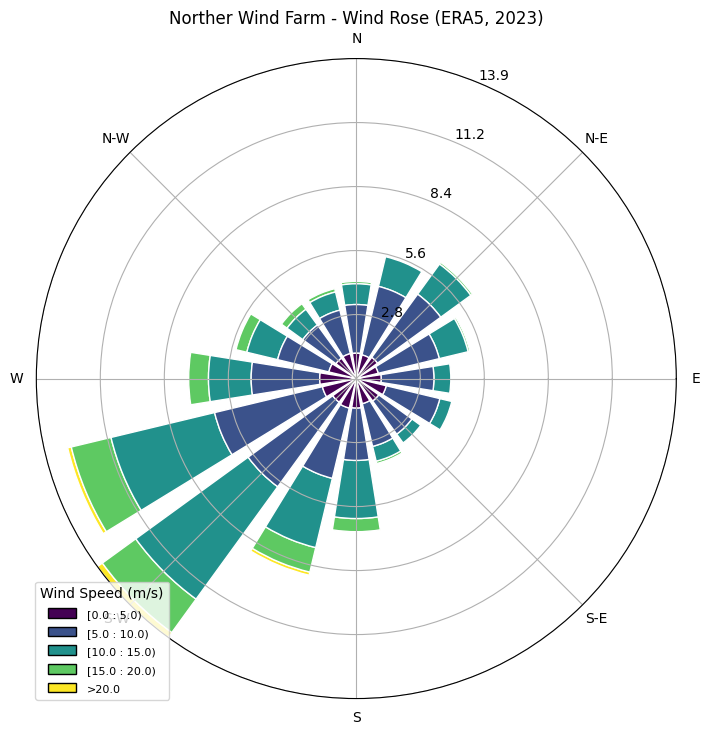

In [ ]:
import matplotlib.pyplot as plt
from windrose import WindroseAxes
import os
from pathlib import Path

fig = plt.figure(figsize=(8, 8))
ax = WindroseAxes.from_ax(fig=fig)
ax.bar(
wd_era5, ws_era5,
normed=True,
opening=0.8,
edgecolor='white',
bins=np.arange(0, 25, 5)
)
ax.set_title(
'Norther Wind Farm - Wind Rose (ERA5, 2023)'
)
ax.set_legend(title='Wind Speed (m/s)')

plt.savefig(
    "../figures/ wind_rose_norther_2023.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

### Wind Rose Interpretation


- Winds predominantly originate from the **southwest (SW) and west-southwest (WSW)** sectors, indicating that these are the prevailing wind directions at the site.
- The majority of wind speeds fall within the **10–15 m/s** and **15–20 m/s** ranges, highlighting the strong offshore wind resource available in the North Sea.
- Winds from eastern and southeastern directions occur less frequently and generally have lower wind speeds.
- Since wind mainly travels from the southwest towards the northeast, neighbouring wind farms located southwest of Norther are expected to have the greatest influence on inter-farm wake losses.
- The wind rose will be used to identify the most important wind directions for subsequent wake modelling and uncertainty analysis.
- 
**Note:** The dominant southwesterly wind pattern is consistent with typical North Sea offshore wind conditions and should be reflected in the wake-loss simulations.

In [ ]:
from py_wake.site import XRSite
import xarray as xr
import numpy as np
# Extract arrays from your 'results' list (from Cell 40)
wd_centres = np.array([r[0] for r in results])
# Convert percentage to fraction (0 to 1) for PyWake
sector_freq = np.array([r[1] / 100 for r in results])
weibull_A = np.array([r[2] for r in results])
weibull_k = np.array([r[3] for r in results])
# Create XRSite with sector-wise Weibull parameters
site = XRSite(
ds=xr.Dataset(
data_vars={
'Sector_frequency': ('wd', sector_freq),
'Weibull_A': ('wd', weibull_A),
'Weibull_k': ('wd', weibull_k),
'TI': 0.06,
},
coords={'wd': wd_centres}
)
)
print("PyWake site created successfully!")
print(f"Sectors: {len(wd_centres)}")
print(f"Mean Weibull A: {weibull_A.mean():.2f} m/s")

/rds/general/user/vk825/home/envs/wake_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyWake site created successfully!
Sectors: 12
Mean Weibull A: 9.29 m/s


In [39]:
from py_wake.wind_turbines.generic_wind_turbines import GenericWindTurbine
# Create a generic representation of the MHI Vestas V164-8.0 MW
# using PyWake's built-in GenericWindTurbine generator.
v164_8mw = GenericWindTurbine(
name='V164-8MW',
diameter=164,
hub_height=105,
power_norm=8000,
turbulence_intensity=0.06
)
print(f"Turbine defined: {v164_8mw.name}")
print(f"Diameter: {v164_8mw.diameter()} m")
print(f"Hub height: {v164_8mw.hub_height()} m")


Turbine defined: <bound method WindTurbines.name of <py_wake.wind_turbines.generic_wind_turbines.GenericWindTurbine object at 0x7ddccf233bf0>>
Diameter: 164.0 m
Hub height: 105.0 m


In [40]:
from shapely.geometry import Point
import pandas as pd

# Filter neighbours: within 30km AND Operational
operational_neighbours = neighbours_deduped[
    (neighbours_deduped["distance_km"] <= 50) &
    (neighbours_deduped["status"] == "Production")
].copy()

print(
    f"Found {len(operational_neighbours)} "
    f"operational neighbours within 50 km"
)

Found 13 operational neighbours within 50 km


In [41]:
def place_turbines_in_polygon(
    polygon, n_turbines,
    min_spacing_D=5, rotor_diameter=164
):
    min_spacing = min_spacing_D * rotor_diameter
    bounds = polygon.bounds # gives (min_x, min_y, max_x, max_y)
    area = polygon.area
    estimated_spacing = (np.sqrt(area / n_turbines) * 0.9)
    spacing = max(estimated_spacing, min_spacing)

    x_range = np.arange(
        bounds[0] + spacing/2, bounds[2], spacing
    )
    y_range = np.arange(
        bounds[1] + spacing/2, bounds[3], spacing
    )

    points_x, points_y = [], []
    for x in x_range:
        for y in y_range:
            if polygon.contains(Point(x, y)):
                points_x.append(x)
                points_y.append(y)

    points_x = np.array(points_x)
    points_y = np.array(points_y)

    if len(points_x) > n_turbines:
        idx = np.random.choice(
            len(points_x), n_turbines,
            replace=False
        )
        points_x = points_x[idx]
        points_y = points_y[idx]

    return points_x, points_y
      


In [42]:
# Place turbines in Norther (target farm)
norther_poly = target.geometry.iloc[0]
print(type(norther_poly))
x_norther, y_norther = place_turbines_in_polygon(
    norther_poly, n_turbines=44, min_spacing_D=5
)

# Place turbines in operational neighbours
all_neighbour_x, all_neighbour_y = [], []

for idx, row in operational_neighbours.iterrows():
    n_turb = (
        int(row['n_turbines'])
        if pd.notna(row['n_turbines'])
        else 0
    )
    if n_turb > 0:
        x_i, y_i = place_turbines_in_polygon(
            row['geometry'],
            n_turbines=n_turb,
            min_spacing_D=4
        )
        all_neighbour_x.extend(x_i)
        all_neighbour_y.extend(y_i)

all_neighbour_x = np.array(all_neighbour_x)
all_neighbour_y = np.array(all_neighbour_y)

print(f"Norther turbines placed: {len(x_norther)}")
print(f"Neighbour turbines placed: {len(all_neighbour_x)}")

<class 'shapely.geometry.multipolygon.MultiPolygon'>
Norther turbines placed: 44
Neighbour turbines placed: 457


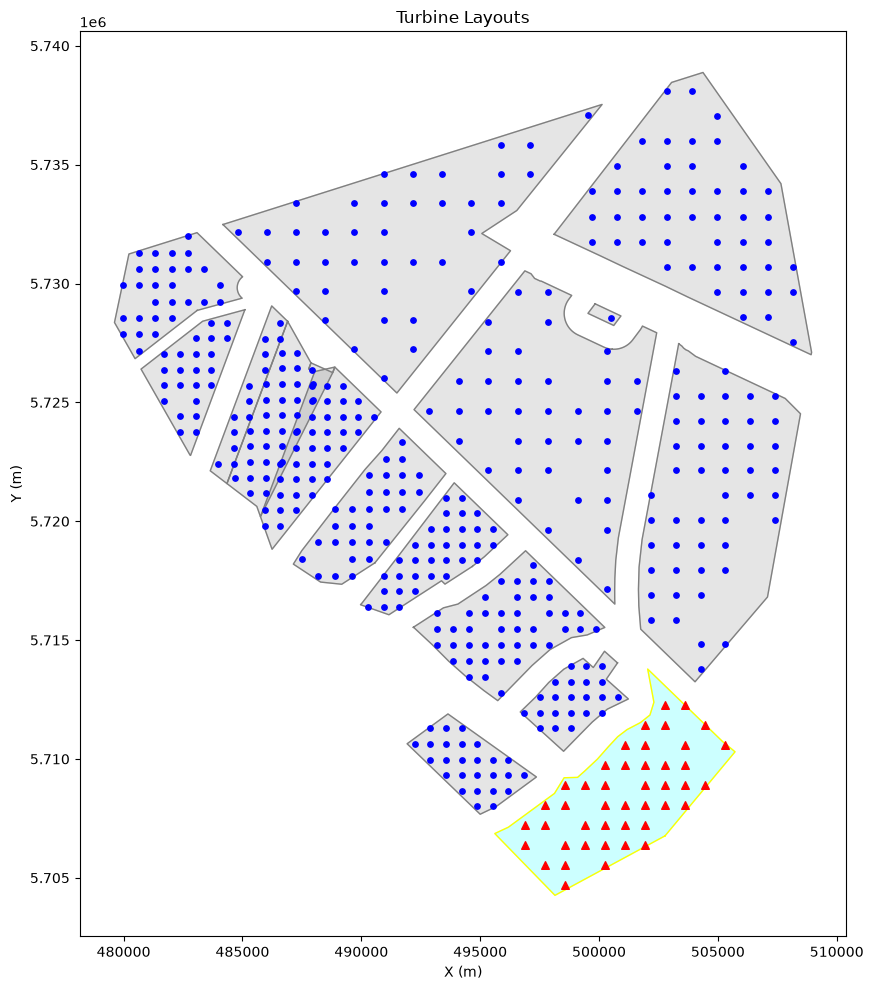

In [43]:
import matplotlib.pyplot as plt
from shapely.geometry import MultiPolygon, Polygon
import numpy as np

fig, ax = plt.subplots(1, 1, figsize=(12, 10))

# Helper to plot any geometry (Polygon or MultiPolygon)
def plot_polygon(geom, ax, fill_color='gray', edge_color='gray'):
    if isinstance(geom, MultiPolygon):
        for poly in geom.geoms:
            x_poly, y_poly = poly.exterior.xy
            ax.fill(x_poly, y_poly, alpha=0.2, color=fill_color)
            ax.plot(x_poly, y_poly, color=edge_color, linewidth=1)
    else:
        x_poly, y_poly = geom.exterior.xy
        ax.fill(x_poly, y_poly, alpha=0.2, color=fill_color)
        ax.plot(x_poly, y_poly, color=edge_color, linewidth=1)

# Plot neighbour farm polygons
for idx, row in operational_neighbours.iterrows():
    plot_polygon(row['geometry'], ax, 'gray', 'gray')

# Plot Norther polygon
plot_polygon(norther_poly, ax, 'cyan', 'yellow')

# Plot neighbour turbines
ax.scatter(
    all_neighbour_x, all_neighbour_y,
    c='blue', s=15, label='Neighbour turbines',
    zorder=3
)

# Plot Norther turbines
ax.scatter(
    x_norther, y_norther,
    c='red', s=30, marker='^',
    label='Norther turbines', zorder=4
)

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_title('Turbine Layouts')
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('../figures/turbine_layout.png', dpi=150)
plt.show()

In [44]:
def estimate_turbines(row):
    if pd.notna(row['n_turbines']) and row['n_turbines'] > 0:
        return int(row['n_turbines'])
    if pd.notna(row['power_mw']) and row['power_mw'] > 0:
        # Estimate assuming 15MW turbines for future farms
        return int((row['power_mw'] / 15.0))
    return 0

In [45]:
all_farms = neighbours_deduped.copy()
all_farms["n_turbines"] = all_farms.apply(estimate_turbines, axis=1)
all_farms

,name,country,status,power_mw,n_turbines,area_sqkm,type_inst,geometry,distance_km
9,Borssele Kavel V,Netherlands,Production,19.0,2,0.589998,NaN,"MULTIPOLYGON (((499836.152 5729146.556, 500922...",14.522078
14,Belwind phase 1,Belgium,Production,165.0,55,14.740745,NaN,"MULTIPOLYGON (((486902.153 5728406.7, 487882.8...",16.582714
15,Rentel,Belgium,Production,309.0,42,23.265816,Grounded,"MULTIPOLYGON (((492188.73 5715538.777, 493455....",2.510876
17,Seamade (SeaStar),Belgium,Production,252.0,30,18.425859,Grounded,"MULTIPOLYGON (((490574.205 5718251.336, 489176...",11.751042
18,Northwester 2,Belgium,Production,219.0,23,11.729325,Grounded,"MULTIPOLYGON (((485101.773 5728897.557, 482816...",20.415853
50,Borssele Kavel II,Netherlands,Production,376.0,47,63.527793,NaN,"MULTIPOLYGON (((503352.064 5727468.359, 503486...",1.000421
51,Borssele Kavel III,Netherlands,Production,351.5,37,71.464014,NaN,"MULTIPOLYGON (((500555.554 5727236.973, 500620...",3.059567
52,Borssele Kavel IV,Netherlands,Production,380.0,40,74.698380,NaN,"MULTIPOLYGON (((484178.546 5732482.796, 500129...",15.687607
55,Borssele I,Netherlands,Production,376.0,47,64.861200,NaN,"MULTIPOLYGON (((498110.248 5732071.393, 503052...",14.890411
111,Mermaid,Belgium,Production,235.2,28,16.267913,NaN,"MULTIPOLYGON (((483097 5728870, 480483 5726839...",23.117381


In [46]:
# select target farm
def plot_target_farm(farm_name):
    target_gdf = gdf_metres.loc[gdf_metres['name'].str.contains(farm_name, case=False)]
    
    distance_km = 50
    distance_m = distance_km * 1000
    
    target = target_gdf.iloc[0]
    target_idx = target.name
    
    neighbours = gdf_metres[
        (gdf_metres.geometry.distance(target.geometry) <= distance_m)
        & (gdf_metres.index != target_idx)
    ].copy()
    
    # remove polygons that overlap/intersect the target
    neighbours = neighbours[
        ~neighbours.geometry.intersects(target.geometry)
    ].copy()
    
    neighbours["distance_km"] = neighbours.geometry.distance(target.geometry) / 1000
    
    print (f"Found {len(neighbours)} neighbours within {distance_km} km of the target farm.")
    
    neighbours[
        ["name", "country", "status", "power_mw", "distance_km", "n_turbines", "area_sqkm", "geometry"]
    ].sort_values("distance_km")
    
    # prepare target and neighbours for folium map
    gdf_web = gdf_metres.to_crs(epsg=4326)
    
    target_web = gpd.GeoDataFrame(
        [target],
        geometry="geometry",
        crs=gdf_metres.crs
    ).to_crs(epsg=4326)
    
    neighbours_web = neighbours.to_crs(epsg=4326)
    
    # create interactive map centred on target farm
    center = [
        target_web.geometry.centroid.y.iloc[0],
        target_web.geometry.centroid.x.iloc[0],
    ]
    
    map = folium.Map(
        location=center,
        zoom_start=9,
        tiles="CartoDB positron"
    )
    
    # add all farms in light grey/blue
    
    folium.GeoJson(
        gdf_web,
        name="All wind farms",
        tooltip=folium.GeoJsonTooltip(
            fields=["name", "country", "status", "power_mw", "n_turbines"],
            aliases=["Farm", "Country", "Status", "Power (MW)", "Number of turbines"],
        ),
        style_function=lambda feature: {
            "fillColor": "lightblue",
            "color": "blue",
            "weight": 1,
            "fillOpacity": 0.25,
        },
    ).add_to(map)
    
    # add target farm in red
    
    folium.GeoJson(
        target_web,
        name="Target farm",
        tooltip=folium.GeoJsonTooltip(
            fields=["name", "country", "status", "power_mw", "n_turbines"],
            aliases=["Target farm", "Country", "Status", "Power (MW)", "Number of Turbines"],
        ),
        style_function=lambda feature: {
            "fillColor": "red",
            "color": "darkred",
            "weight": 3,
            "fillOpacity": 0.7,
        },
    ).add_to(map)
    
    # add neighbouring farms in green
    
    folium.GeoJson(
        neighbours_web,
        name="Neighbouring farms",
        tooltip=folium.GeoJsonTooltip(
            fields=["name", "country", "status", "power_mw", "distance_km", "n_turbines"],
            aliases=["Farm", "Country", "Status", "Power (MW)", "Distance to target (km)", "Number of Turbines"],
        ),
        style_function=lambda feature: {
            "fillColor": "green",
            "color": "darkgreen",
            "weight": 2,
            "fillOpacity": 0.6,
        },
    ).add_to(map)
    
    folium.LayerControl().add_to(map)
    
    return map

In [47]:
plot_target_farm("rampion")

Found 1 neighbours within 50 km of the target farm.


/tmp/ipykernel_243166/2237168380.py:42: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  target_web.geometry.centroid.y.iloc[0],
/tmp/ipykernel_243166/2237168380.py:43: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  target_web.geometry.centroid.x.iloc[0],


In [48]:
# distance_km = 50
# distance_m = distance_km * 1000

# target_idx = candidate_farms.index[0]
# target = gdf_metres.loc[target_idx]
# print(type(target))

# neighbours = gdf_metres[
#     (gdf_metres.geometry.distance(target.geometry) <= distance_m)
#     & (gdf_metres.index != target_idx)
# ].copy()

# # remove polygons that overlap/intersect the target
# neighbours = neighbours[
#     ~neighbours.geometry.intersects(target.geometry)
# ].copy()

# neighbours["distance_km"] = neighbours.geometry.distance(target.geometry) / 1000

# print (f"Found {len(neighbours)} neighbours within {distance_km} km of the target farm.")

# neighbours[
#     ["name", "country", "status", "power_mw", "distance_km", "n_turbines", "area_sqkm", "geometry"]
# ].sort_values("distance_km")

In [49]:
# # prepare target and neighbours for folium map
# gdf_web = gdf_metres.to_crs(epsg=4326)

# target_web = gpd.GeoDataFrame(
#     [target],
#     geometry="geometry",
#     crs=gdf_metres.crs
# ).to_crs(epsg=4326)

# neighbours_web = neighbours.to_crs(epsg=4326)

In [50]:
# # create interactive map centred on target farm
# center = [
#     target_web.geometry.centroid.y.iloc[0],
#     target_web.geometry.centroid.x.iloc[0],
# ]

# map = folium.Map(
#     location=center,
#     zoom_start=9,
#     tiles="CartoDB positron"
# )

In [51]:
# # add all farms in light grey/blue

# folium.GeoJson(
#     gdf_web,
#     name="All wind farms",
#     tooltip=folium.GeoJsonTooltip(
#         fields=["name", "country", "status", "power_mw", "n_turbines"],
#         aliases=["Farm", "Country", "Status", "Power (MW)", "Number of turbines"],
#     ),
#     style_function=lambda feature: {
#         "fillColor": "lightblue",
#         "color": "blue",
#         "weight": 1,
#         "fillOpacity": 0.25,
#     },
# ).add_to(map)

In [52]:
# # add target farm in red

# folium.GeoJson(
#     target_web,
#     name="Target farm",
#     tooltip=folium.GeoJsonTooltip(
#         fields=["name", "country", "status", "power_mw", "n_turbines"],
#         aliases=["Target farm", "Country", "Status", "Power (MW)", "Number of Turbines"],
#     ),
#     style_function=lambda feature: {
#         "fillColor": "red",
#         "color": "darkred",
#         "weight": 3,
#         "fillOpacity": 0.7,
#     },
# ).add_to(map)

In [53]:
# folium.LayerControl().add_to(map)

# map